In [1]:
import time
import json
import os
import sys
import math
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer

In [48]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0,IsNew32=False)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=100,adc_last_gap=100)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 10,delay3=50)
chip.add_compiler("../compiler/code/")
chip.compensation.initop("../chip_data/chip6_/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 53337
正在编译文件:  ../compiler/code/read_point3_from_col.txt
正在编译文件:  ../compiler/code/read_point3_from_row.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


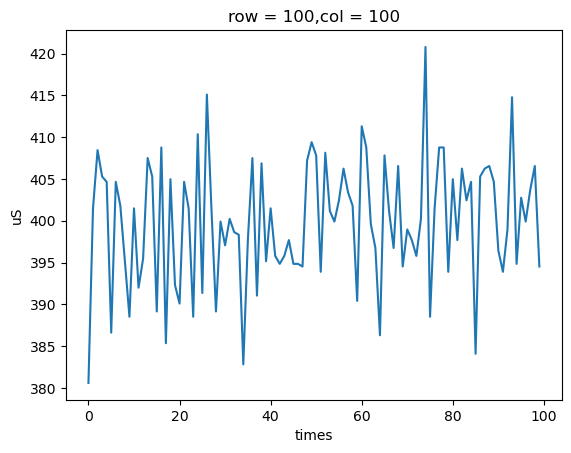

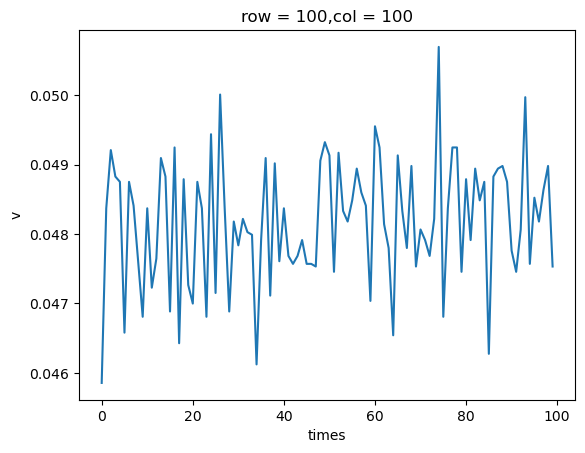

In [49]:
need_read = np.zeros((256,256),dtype=bool)
row = 100
col = 100
need_read[row,col]=True
ans = []
vol = []
for i in range(100):
    voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    ans.append(cond[need_read])
    vol.append((voltage-voltage_base)[need_read])

plt.plot(ans)
plt.title(f"row = {row},col = {col}")
plt.xlabel("times")
plt.ylabel("uS")
plt.show()

plt.plot(vol)
plt.title(f"row = {row},col = {col}")
plt.xlabel("times")
plt.ylabel("v")
plt.show()


In [33]:
col=11
ans = chip.compensation.get_compare(chip=chip,col=col,value=0.81,oddoffset=-1)

1.1487548448133793


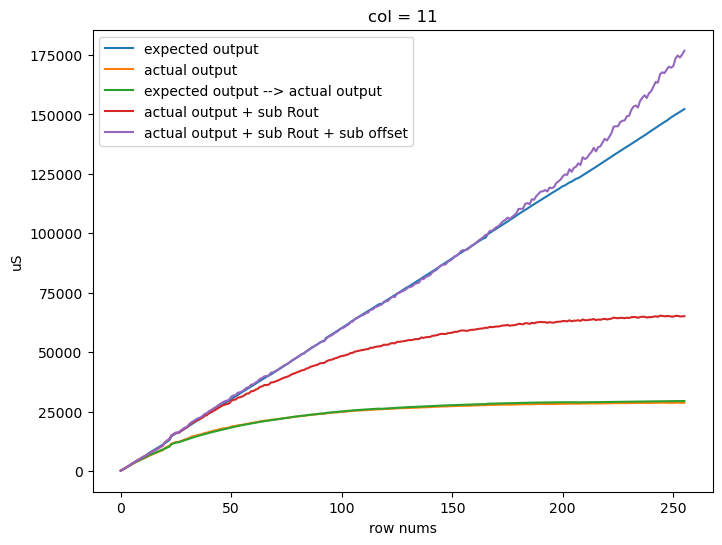

In [34]:
plt.figure(figsize=(8,6))
plt.plot(ans[0],label = "expected output")
plt.plot(ans[1],label = "actual output")
plt.plot(ans[2],label = "expected output --> actual output")
plt.plot(ans[3],label = "actual output + sub Rout")
plt.plot(ans[4],label = "actual output + sub Rout + sub offset")
plt.title(f"col = {col}")
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

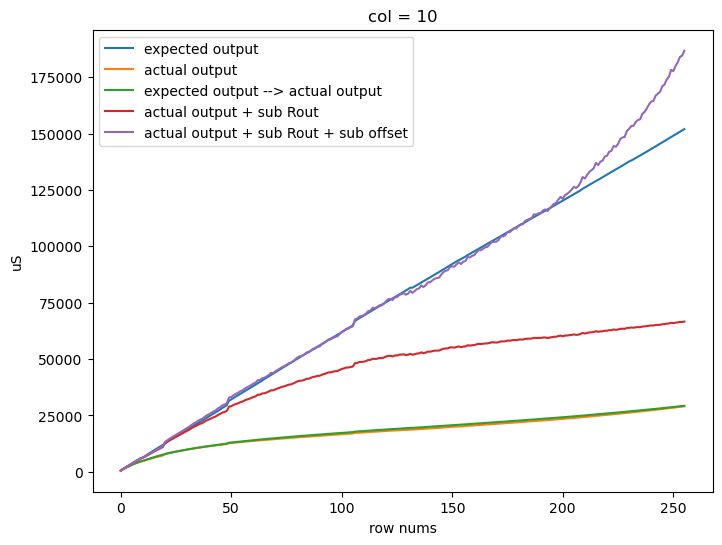

In [28]:
col=10
ans = chip.compensation.get_compare(chip=chip,col=col,value=0.75,oddoffset=-1)
plt.figure(figsize=(8,6))
plt.plot(ans[0],label = "expected output")
plt.plot(ans[1],label = "actual output")
plt.plot(ans[2],label = "expected output --> actual output")
plt.plot(ans[3],label = "actual output + sub Rout")
plt.plot(ans[4],label = "actual output + sub Rout + sub offset")
plt.title(f"col = {col}")
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

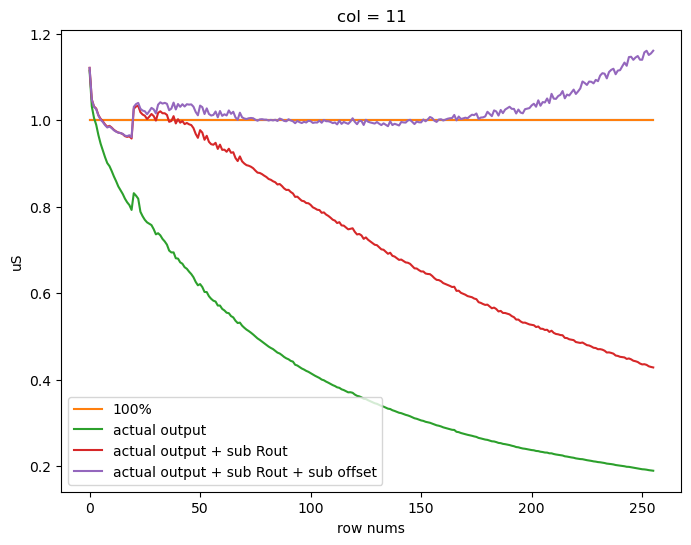

In [35]:
plt.figure(figsize=(8,6))

plt.plot(np.ones(256))
plt.plot(np.ones(256),label = "100%")
# plt.plot(ans[0],label = "expected output")
plt.plot(ans[1]/ans[0],label = "actual output")
# plt.plot(ans[2]/ans[0],label = "expected output --> actual output")
plt.plot(ans[3]/ans[0],label = "actual output + sub Rout")
plt.plot(ans[4]/ans[0],label = "actual output + sub Rout + sub offset")

plt.title(f"col = {col}")
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

NameError: name 'col' is not defined

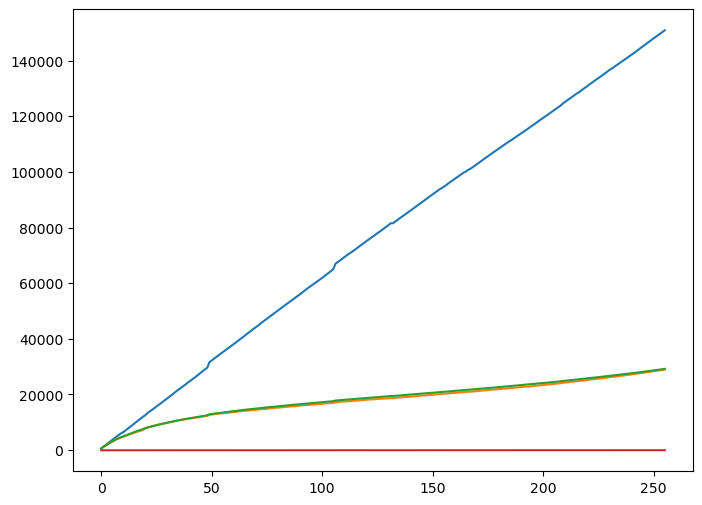

In [4]:
plt.figure(figsize=(8,6))
plt.plot(ans[0],label = "expected output")
plt.plot(ans[1],label = "actual output")
plt.plot(ans[2],label = "expected output --> actual output")
plt.plot(ans[3],label = "expected output --> actual output")
plt.title(f"col = {col}")
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

In [20]:

point_read = np.zeros((256,256))
sum_read = np.zeros((1,256))
num = 40
for i in range(num):
    voltage_base = chip.read_point3(0,256,0,256,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point3(0,256,0,256,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    print(np.max(voltage))
    resistence = chip.voltage_to_resistance(voltage=voltage-voltage_base)

    point_read+=resistence

    voltage_base=chip.compute(crossbar=np.ones((256,256)),read_voltage=0,tg=5,gain=3,from_row=True,out_type=0)
    voltage=chip.compute(crossbar=np.ones((256,256)),read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=0)
    # print(voltage.shape)
    print(np.max(voltage))
    resistence = chip.voltage_to_resistance(voltage = voltage-voltage_base)

    sum_read+=resistence

point_read=point_read/num
sum_read=sum_read/num


KeyboardInterrupt: 

# 1.计算R_out和R_wire

In [ ]:
def get_A_B_C(pos,num,from_row,sub_base=False):
    need_read = np.zeros((256,256),dtype=bool)
    weight_pos = np.ix_([i for i in range(pos[0],pos[1])], [num]) if from_row else np.ix_([num],[i for i in range(pos[0],pos[1])])
    need_read[weight_pos] = True
    gain = 1 if (pos[1]-pos[0])<15 else 3
    if sub_base:
        voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=from_row,out_type=0)
    if sub_base:
        voltage -= voltage_base
    a = chip.voltage_to_resistance(voltage = voltage)

    # 如果第二段开的行太少,3挡增益不太够
    need_read[:] = False
    weight_pos = np.ix_([i for i in range(pos[1],pos[2])], [num]) if from_row else np.ix_([num],[i for i in range(pos[1],pos[2])])
    need_read[weight_pos] = True
    gain = 1 if (pos[2]-pos[1])<15 else 3
    if sub_base:
        voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=from_row,out_type=0)
    if sub_base:
        voltage -= voltage_base
    b = chip.voltage_to_resistance(voltage = voltage)

    need_read[:] = False
    weight_pos = np.ix_([i for i in range(pos[0],pos[2])], [num]) if from_row else np.ix_([num],[i for i in range(pos[0],pos[2])])
    need_read[weight_pos] = True
    gain = 1 if (pos[2]-pos[0])<15 else 3
    if sub_base:
            voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=from_row,out_type=0)
    if sub_base:
        voltage -= voltage_base
    c = chip.voltage_to_resistance(voltage = voltage)

    if from_row:
        return a[0,num],b[0,num],c[0,num]
    else:
        return a[num,0],b[num,0],c[num,0]
    
def get_out(pos,num,from_row,sub_base=False):
    a,b,c = get_A_B_C(pos=pos,num=num,from_row=from_row,sub_base=sub_base)

    base1 = ((c-a)/(c-b))**0.5
    base2 = ((c-b)/(c-a))**0.5

    if base1>1:
        R2 = (b-c)*(1+base1)
        R = b-R2
    elif base2>1:
        R1 = (a-c)*(1+base2)
        R = a-R1

    return R

In [ ]:
# R=get_out((0,6,56),10,from_row=False)
# print(R)

# R=get_out((200,252,256),11,from_row=False)
# print(R)

# R=get_out((0,6,56),11,from_row=True)-get_out((200,250,256),11,from_row=True)
# print(R)

# R=get_out((200,250,256),200,from_row=True)
# print(R)

R=(get_out((200,204,256),11,from_row=True)-get_out((0,4,56),11,from_row=True))/200*1000
print(R)

0.13527682275870673


In [ ]:
nums = 50
# ----------------------------------------------------------------列的
R_out = np.zeros((256,nums))
R_wire = np.zeros((256,nums))
for col in range(256):
    print("列",col)
    for j in range(nums):
        if col%2==0:
            R_out[col,j] = get_out((200,250,256),col,from_row=True)
            R_wire[col,j] = get_out((0,50,56),col,from_row=True)
        else:
            R_out[col,j] = get_out((0,6,56),col,from_row=True)
            R_wire[col,j] = get_out((200,206,256),col,from_row=True)

nums = 50
# ----------------------------------------------------------------行的
# R_out = np.zeros((256,nums))
# R_wire = np.zeros((256,nums))
# for row in range(256):
#     print("行",row)
#     for j in range(nums):
#         if row%2==0:
#             R_out[row,j] = get_out((0,6,56),row,from_row=False)
#             R_wire[row,j] = get_out((200,206,256),row,from_row=False)
#         else:
#             R_out[row,j] = get_out((200,250,256),row,from_row=False)
#             R_wire[row,j] = get_out((0,50,56),row,from_row=False)


列 0
列 1
列 2
列 3
列 4
列 5
列 6
列 7
列 8
列 9
列 10
列 11
列 12
列 13
列 14
列 15
列 16
列 17
列 18
列 19
列 20
列 21
列 22
列 23
列 24
列 25
列 26
列 27
列 28
列 29
列 30
列 31
列 32
列 33
列 34
列 35
列 36
列 37
列 38
列 39
列 40
列 41
列 42
列 43
列 44
列 45
列 46
列 47
列 48
列 49
列 50
列 51
列 52
列 53
列 54
列 55
列 56
列 57
列 58
列 59
列 60
列 61
列 62
列 63
列 64
列 65
列 66
列 67
列 68
列 69
列 70
列 71
列 72
列 73
列 74
列 75
列 76
列 77
列 78
列 79
列 80
列 81
列 82
列 83
列 84
列 85
列 86
列 87
列 88
列 89
列 90
列 91
列 92
列 93
列 94
列 95
列 96
列 97
列 98
列 99
列 100
列 101
列 102
列 103
列 104
列 105
列 106
列 107
列 108
列 109
列 110
列 111
列 112
列 113
列 114
列 115
列 116
列 117
列 118
列 119
列 120
列 121
列 122
列 123
列 124
列 125
列 126
列 127
列 128
列 129
列 130
列 131
列 132
列 133
列 134
列 135
列 136
列 137
列 138
列 139
列 140
列 141
列 142
列 143
列 144
列 145
列 146
列 147
列 148
列 149
列 150
列 151
列 152
列 153
列 154
列 155
列 156
列 157
列 158
列 159
列 160
列 161
列 162
列 163
列 164
列 165
列 166
列 167
列 168
列 169
列 170
列 171
列 172
列 173
列 174
列 175
列 176
列 177
列 178
列 179
列 180
列 181
列 182
列 183
列 184


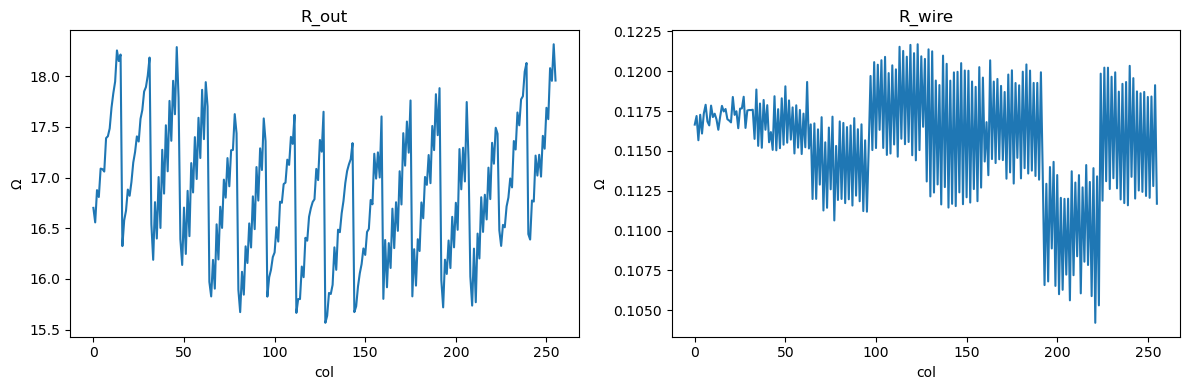

In [ ]:
r_out_path = "../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_no_sub_base.npy"
r_wire_path = "../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_no_sub_base.npy"
# r_out_path = "../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_times=2.npy"
# r_wire_path = "../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_times=2.npy"
R_out_mean = np.mean(R_out,axis=1)*1000
# np.save(r_out_path,R_out_mean)

R_out_read = np.load(r_out_path)
R_wire_mean = (np.mean(R_wire,axis=1)*1000-R_out_read)/200
# np.save(r_wire_path,R_wire_mean)

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(R_out_mean)
plt.title("R_out")
plt.xlabel("col")
plt.ylabel("Ω")

plt.subplot(1, 2, 2)
plt.plot(R_wire_mean)
plt.title("R_wire")
plt.xlabel("col")
plt.ylabel("Ω")


plt.tight_layout()
plt.show()

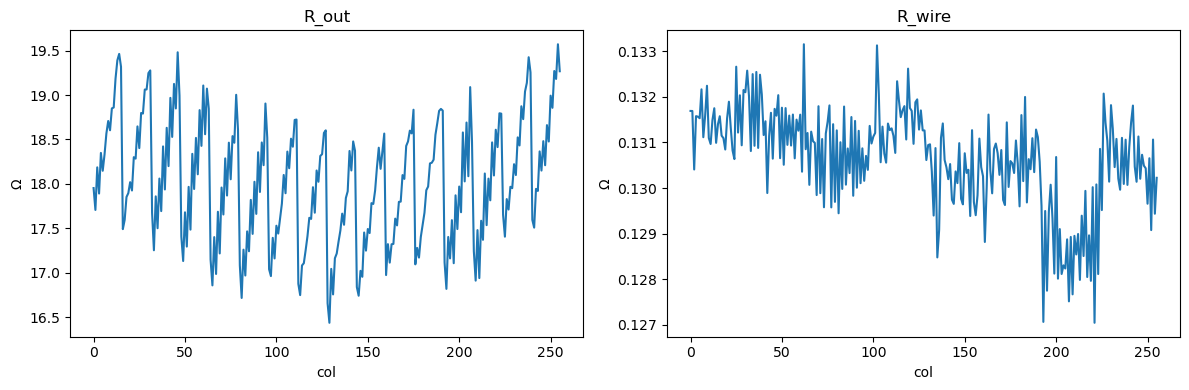

In [ ]:
r_out = np.load("../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_times=2.npy")
r_w = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_times=2.npy")
# r_out = np.load("../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_no_sub_base.npy")
# r_w = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_no_sub_base.npy")

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(r_out)
plt.title("R_out")
plt.xlabel("col")
plt.ylabel("Ω")

plt.subplot(1, 2, 2)
plt.plot(r_w)
plt.title("R_wire")
plt.xlabel("col")
plt.ylabel("Ω")


plt.tight_layout()
plt.show()

# 2.计算实际电导值

In [ ]:
r_out = np.load("../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_times=2.npy")
r_w = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_times=2.npy")

# r_out = np.load("../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_no_sub_base.npy")
# r_w = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_no_sub_base.npy")


In [ ]:
row = [i for i in range(0,256)]
col = 154
weight_pos = np.ix_(row, [col])
need_read = np.zeros((256,256),dtype=bool)
need_read[weight_pos] = True

voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
# need_write = cond<400 & need_read
# chip.write_point2(crossbar=need_write,write_voltage=5,tg=2,pulse_width=1000e-6,set_device=True)
resistance_real = chip.voltage_to_resistance(voltage=voltage-voltage_base)[weight_pos]*1e3 - r_out[col]


# 每一行有不同的列电阻
for i in row:
    r_w_sum = (255-i)*r_w[col] if col%2==0 else i*r_w[col]
    resistance_real[i,0] -= r_w_sum

real_cond = 1/resistance_real*1e6
print(np.mean(real_cond))
plt.plot(real_cond.flatten())
plt.title(f"col={col} real_cond")
plt.ylabel("uS")
plt.xlabel("row")
plt.show()

cond0_ans = [np.sum(real_cond[0:i+1]) for i in range(0,256)]

In [ ]:
cond1_ans = []
cond2_ans = []
cond3_ans = []
for k in range(0,256):
    print("k=",k)
    row = [i for i in range(0,k+1)]

    # selected_elements = random.sample(my_list, 50)
    weight_pos = np.ix_(row, [col])
    need_read = np.zeros((256,256),dtype=bool)
    need_read[weight_pos] = True


    row_min,row_max = np.min(row),np.max(row)
    r_w_sum = (255-row_max)*r_w[col] if col%2==0 else row_min*r_w[col]
    # if len(row)<40:
    #     r_w_sum = 0


    gain = 3#1 if len(row)<15 else 3
    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=True,out_type=0)
    resistance = chip.voltage_to_resistance(voltage=voltage-voltage_base)[0,col]*1e3
    cond2 = 1/resistance*1e6
    cond2_ans.append(cond2)

    n = len(row)
    a = (n*(n-1)/2)
    b = n+n*(n+1)*(n-1)/6*(r_w[col]+r_w[col]**2+r_w[col]**3)/np.mean(real_cond)
    # print(a,b,a/b,n/b)
    resistance = resistance - r_out[col] - r_w_sum
    # if gain == 1:
    #     resistance -=  r_out[col]
    cond1 = 1/resistance*1e6
    cond1_ans.append(cond1)

    resistance -= a/b*r_w[col]
    cond3 = 1/resistance*1e6*0.925
    cond3_ans.append(cond3)

In [ ]:
num=256
plt.plot(cond0_ans[:num],label = "real")
plt.plot(cond3_ans[:num],label = "Compensation2")
plt.plot(cond1_ans[:num],label = "Compensation only r_out")
plt.plot(cond2_ans[:num],label ="No Compensation")

print(cond0_ans)
print(cond1_ans)
print(cond2_ans)
print(cond3_ans)
print(len(cond0_ans))
print(len(cond1_ans))
print(len(cond2_ans))
plt.title(f"col={col}")
plt.ylabel("uS")
plt.xlabel("try times")
plt.legend()
plt.show()

plt.plot(np.array(cond3_ans)/np.array(cond0_ans),label = "Compensation2/real")
plt.plot(np.array(cond1_ans)/np.array(cond0_ans),label = "Compensation only r_out/real")
plt.plot(np.array(cond2_ans)/np.array(cond0_ans),label = "No Compensation/real")

print(np.array(cond3_ans)/np.array(cond0_ans))
plt.title(f"col={col}")
# plt.ylabel("uS")
plt.xlabel("try times")
plt.legend()
plt.show()

# 3.由真实值重构最后的累加值

In [ ]:
r_out = np.load("../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_times=2.npy")
r_w = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_times=2.npy")

645.1935328866741


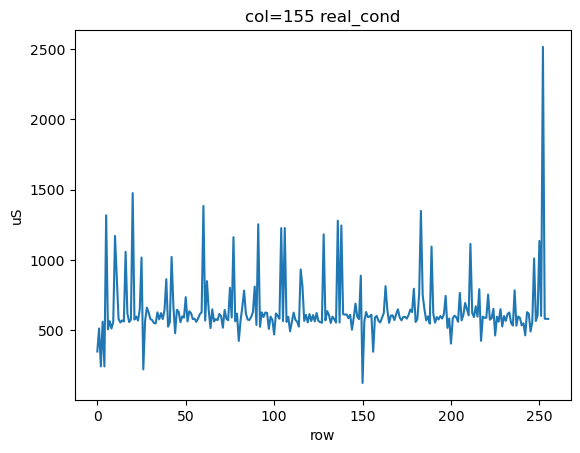

In [ ]:
row = [i for i in range(0,256)]
col = 155
weight_pos = np.ix_(row, [col])
need_read = np.zeros((256,256),dtype=bool)
need_read[weight_pos] = True

voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
# need_write = cond<400 & need_read
# chip.write_point2(crossbar=need_write,write_voltage=5,tg=2,pulse_width=1000e-6,set_device=True)
resistance_real = chip.voltage_to_resistance(voltage=voltage-voltage_base)[weight_pos]*1e3 - r_out[col]


# 每一行有不同的列电阻
for i in row:
    r_w_sum = (255-i)*r_w[col] if col%2==0 else i*r_w[col]
    resistance_real[i,0] -= r_w_sum

real_cond = 1/resistance_real*1e6
print(np.mean(real_cond))
plt.plot(real_cond.flatten())
plt.title(f"col={col} real_cond")
plt.ylabel("uS")
plt.xlabel("row")
plt.show()

cond0_ans = [np.sum(real_cond[0:i+1]) for i in range(0,256)]

In [ ]:
cond1_ans = []
cond2_ans = []
cond3_ans = []
for k in range(0,256):
    print("k=",k)
    row = [i for i in range(0,k+1)]

    # selected_elements = random.sample(my_list, 50)
    weight_pos = np.ix_(row, [col])
    need_read = np.zeros((256,256),dtype=bool)
    need_read[weight_pos] = True


    row_min,row_max = np.min(row),np.max(row)
    r_w_sum = (255-row_max)*r_w[col] if col%2==0 else row_min*r_w[col]
    # if len(row)<40:
    #     r_w_sum = 0


    gain = 3#1 if len(row)<15 else 3
    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=True,out_type=0)
    resistance = chip.voltage_to_resistance(voltage=voltage-voltage_base)[0,col]*1e3
    cond2 = 1/resistance*1e6
    cond2_ans.append(cond2)

    n = len(row)
    a = (n*(n-1)/2)
    b = n+n*(n+1)*(n-1)/6*(r_w[col]+r_w[col]**2+r_w[col]**3)/np.mean(real_cond)
    # print(a,b,a/b,n/b)
    resistance = resistance - r_out[col] - r_w_sum
    # if gain == 1:
    #     resistance -=  r_out[col]
    cond1 = 1/resistance*1e6
    cond1_ans.append(cond1)

    resistance -= a/b*r_w[col]
    cond3 = 1/resistance*1e6*0.925
    cond3_ans.append(cond3)

k= 0
k= 1
k= 2
k= 3
k= 4
k= 5
k= 6
k= 7
k= 8
k= 9
k= 10
k= 11
k= 12
k= 13
k= 14
k= 15
k= 16
k= 17
k= 18
k= 19
k= 20
k= 21
k= 22
k= 23
k= 24
k= 25
k= 26
k= 27
k= 28
k= 29
k= 30
k= 31
k= 32
k= 33
k= 34
k= 35
k= 36
k= 37
k= 38
k= 39
k= 40
k= 41
k= 42
k= 43
k= 44
k= 45
k= 46
k= 47
k= 48
k= 49
k= 50
k= 51
k= 52
k= 53
k= 54
k= 55
k= 56
k= 57
k= 58
k= 59
k= 60
k= 61
k= 62
k= 63
k= 64
k= 65
k= 66
k= 67
k= 68
k= 69
k= 70
k= 71
k= 72
k= 73
k= 74
k= 75
k= 76
k= 77
k= 78
k= 79
k= 80
k= 81
k= 82
k= 83
k= 84
k= 85
k= 86
k= 87
k= 88
k= 89
k= 90
k= 91
k= 92
k= 93
k= 94
k= 95
k= 96
k= 97
k= 98
k= 99
k= 100
k= 101
k= 102
k= 103
k= 104
k= 105
k= 106
k= 107
k= 108
k= 109
k= 110
k= 111
k= 112
k= 113
k= 114
k= 115
k= 116
k= 117
k= 118
k= 119
k= 120
k= 121
k= 122
k= 123
k= 124
k= 125
k= 126
k= 127
k= 128
k= 129
k= 130
k= 131
k= 132
k= 133
k= 134
k= 135
k= 136
k= 137
k= 138
k= 139
k= 140
k= 141
k= 142
k= 143
k= 144
k= 145
k= 146
k= 147
k= 148
k= 149
k= 150
k= 151
k= 152
k= 153
k= 154
k= 155
k= 156
k= 157
k= 1

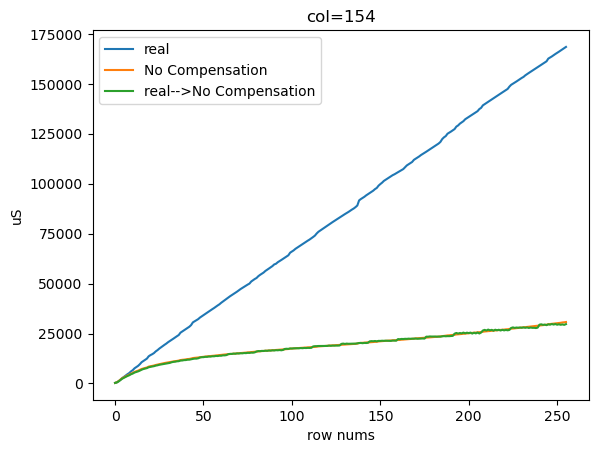

In [ ]:
rw = r_w[col]
real_r_sum = np.zeros((256))
for i in range(256):
    if i==0:
        real_r_sum[i] = resistance_real[i,0]
    else:
        real_r_sum[i] = (real_r_sum[i-1]+rw)*resistance_real[i,0]/((real_r_sum[i-1]+rw)+resistance_real[i,0])

for i in range(256):
    r_w_sum = (255-i)*rw if col%2==0 else i*rw
    real_r_sum[i] += r_w_sum + r_out[i]

real_c_sum = 1/real_r_sum*1e6

num=256
plt.plot(cond0_ans[:num],label = "real")
plt.plot(cond2_ans[:num],label ="No Compensation")
plt.plot(real_c_sum[:num],label = "real-->No Compensation")

plt.title(f"col={col}")
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

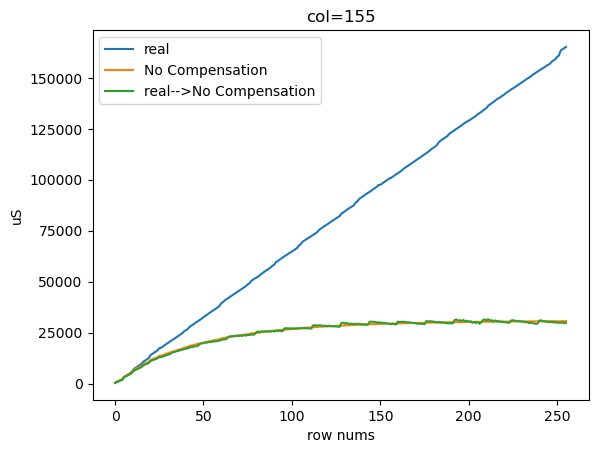

In [ ]:
rw = r_w[col]
real_r_sum = np.zeros((256))
for i in range(256):
    if i==0:
        real_r_sum[i] = resistance_real[i,0]
    else:
        real_r_sum[i] = (real_r_sum[i-1]+rw)*resistance_real[i,0]/((real_r_sum[i-1]+rw)+resistance_real[i,0])

for i in range(256):
    r_w_sum = (255-i)*rw if col%2==0 else 0
    real_r_sum[i] += r_w_sum + r_out[i]

real_c_sum = 1/real_r_sum*1e6


num=256
plt.plot(cond0_ans[:num],label = "real")
plt.plot(cond2_ans[:num],label ="No Compensation")
plt.plot(real_c_sum[:num],label = "real-->No Compensation")

plt.title(f"col={col}")
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

# 3. 其他值

In [ ]:
col=150
row = [4]

# selected_elements = random.sample(my_list, 50)
weight_pos = np.ix_(row, [col])
need_read = np.zeros((256,256),dtype=bool)
need_read[weight_pos] = True





chip.set_cim_reset()
voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
resistance = chip.voltage_to_resistance(voltage=voltage)[weight_pos]*1e3
print("电压",np.max(voltage))
print(1111,resistance)
resistance = resistance- - r_out[col]
for i in row:
    r_w_sum = (255-i)*r_w[col] if col%2==0 else i*r_w[col]
    resistance[0,0] -= r_w_sum
    print(r_w_sum,r_out[col])
real_cond = 1/resistance*1e6
print(real_cond)





row_min,row_max = np.min(row),np.max(row)
r_w_sum = (255-row_max)*r_w[col] if col%2==0 else row_min*r_w[col]

gain = 1 if len(row)<15 else 3
voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=True,out_type=0)
chip.set_cim_reset()
voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=True,out_type=0)
print("电压",np.max(voltage))
resistance = chip.voltage_to_resistance(voltage=voltage)[0,col]*1e3
print(1111,resistance)
resistance_real = resistance- - r_out[col] - r_w_sum
cond1 = 1/resistance_real*1e6

print(cond1,r_out[col],r_w_sum)



电压 0.17345957823419905
1111 [[694.58257207]]
32.82150571725563 17.49205480865658
[[1472.20523373]]
电压 0.16663106173894468
1111 723.0464641025641
1412.9941507085523 17.49205480865658 32.82150571725563


In [ ]:
import random

cond0_ans = []
cond1_ans = []
cond2_ans = []
cond3_ans = []
for k in range(0,40):
    r_w = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_times=2.npy")
    print("k=",k)
    row = [i for i in range(0,100)]

    # row = random.sample(row, 50)
    print(len(row))
    weight_pos = np.ix_(row, [col])
    need_read = np.zeros((256,256),dtype=bool)
    need_read[weight_pos] = True

    # voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    # voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    # cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    # resistance = chip.voltage_to_resistance(voltage=voltage-voltage_base)[weight_pos]*1e3 - r_out[col]
    # real_cond = 1/resistance*1e6
    # cond0_ans.append(np.sum(real_cond))

    # # 每一行有不同的列电阻
    # for i,v in enumerate(row):
    #     r_w_sum = (255-v)*r_w[col] if col%2==0 else v*r_w[col]
    #     resistance[i,0] -= r_w_sum


    row_min,row_max = np.min(row),np.max(row)
    r_w_sum = (255-row_max)*r_w[col] if col%2==0 else row_min*r_w[col]


    r_w = r_w*200/100
    gain = 3#1 if len(row)<15 else 3
    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=True,out_type=0)
    resistance = chip.voltage_to_resistance(voltage=voltage-voltage_base)[0,col]*1e3
    cond2 = 1/resistance*1e6
    cond2_ans.append(cond2)

    n = len(row)
    a = (n*(n-1)/2)
    b = n+n*(n+1)*(n-1)/6*(r_w[col]+r_w[col]**2+r_w[col]**3)/np.mean(real_cond)
    print(a,b,a/b,n/b)
    resistance = resistance - r_out[col] - r_w_sum
    cond1 = 1/resistance*1e6
    cond1_ans.append(cond1)

    resistance -= a/b*r_w[col]
    cond3 = 1/resistance*1e6*0.925#*b/n
    cond3_ans.append(cond3)

In [ ]:
print(resistance_real.shape)

(256, 1)


In [ ]:
cond1_ans = []
cond2_ans = []
cond3_ans = []
for k in range(0,256):
    print("k=",k)
    row = [i for i in range(0,k+1)]

    # selected_elements = random.sample(my_list, 50)
    weight_pos = np.ix_(row, [col])
    need_read = np.zeros((256,256),dtype=bool)
    need_read[weight_pos] = True


    row_min,row_max = np.min(row),np.max(row)
    r_w_sum = (255-row_max)*r_w[col] if col%2==0 else row_min*r_w[col]
    # if len(row)<40:
    #     r_w_sum = 0


    gain = 3#1 if len(row)<15 else 3
    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=True,out_type=0)
    resistance = chip.voltage_to_resistance(voltage=voltage-voltage_base)[0,col]*1e3
    cond2 = 1/resistance*1e6
    cond2_ans.append(cond2)

    n = len(row)
    a = (n*(n-1)/2)
    b = n+n*(n+1)*(n-1)/6*(r_w[col]+r_w[col]**2+r_w[col]**3)/np.mean(real_cond)
    # print(a,b,a/b,n/b)
    resistance = resistance - r_out[col] - r_w_sum
    # if gain == 1:
    #     resistance -=  r_out[col]
    cond1 = 1/resistance*1e6
    cond1_ans.append(cond1)

    resistance -= a/b*r_w[col]
    cond3 = 1/resistance*1e6*0.925
    cond3_ans.append(cond3)

In [ ]:
resistance = 1/np.array(cond2_ans)*1e6

# 实际每个单元的电阻，已经减去col的线阻和r_out
real_r = 1/real_cond[i]*1e6
r_col = R_wire[col]

real_r_cal = []
for i in range(256):
    # 每次迭代时都要用到v和电流
    v_real = 0.1
    current = v_real/resistance[i]
    r_now = resistance[i]
    for k in range(0,k+1):
        
        if k==0:
            row_min,row_max = 0,i
            r_w_sum = (255-row_max)*r_w[col] if col%2==0 else row_min*r_w[col]
            r = r_now - r_out[col] - r_w_sum
            real_r_cal.append(r)
            # 实际分压为
            v_real = current*r
            current -= v_real/real_r[k]
        else:
            r = 


3689.5642
[3587.15683924]
1553.5007157894736
[3221.54720567]
856.8277143787303
[1862.96416184]
554.7632101176885
[1323.94720833]
402.68608379446647
[1194.00803527]
343.3272046091967
[1647.24976998]
294.94461666044083
[1469.97878645]
261.55419918840585
[1523.14510828]
240.410059770115
[1752.31437697]
214.81886513399536
[1187.83240941]
201.33020687193215
[1663.56855613]
183.20476565926094
[1063.28618512]
173.85593720136518
[1656.42469537]
165.0949793622582
[1657.47826095]
145.75257158743395
[1229.08879178]
136.5647303985413
[984.71058317]
132.25832492431888
[1658.79536178]
128.2152115431646
[1755.55598347]
124.26451765821284
[1640.77973331]
118.23906179521877
[853.4565339]
115.07287093942053
[1701.92811884]
112.91664871850097
[2141.55608238]
110.51264755480607
[1761.3834564]
107.21308793456032
[1191.61450032]
104.93835068054443
[1648.83146852]
102.61734194558622
[1295.25389722]
100.4160122581881
[1522.50917936]
98.6400752587018
[1638.35236149]
97.06943158674322
[1522.77171699]
95.4089171

In [ ]:
good_device = np.load("../data/good_point_100_100_1_4.npy")

In [ ]:

weight_pos = np.ix_([i for i in range(256)], [i for i in range(256)])


voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_add = chip.voltage_to_cond(voltage=voltage)[weight_pos]
cond_add = np.sum(cond_add,axis=0)

voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=3,from_row=True,out_type=0)
voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=0)
cond_sum = chip.voltage_to_cond(voltage=voltage)
print(np.max(voltage))
plt.plot(cond_add,label="add")
plt.plot(cond_sum[0],label="sum")
plt.legend()
plt.show()

plt.plot((cond_add-cond_sum[0])/cond_add,label="sub")
plt.legend()
plt.show()

In [ ]:
change256 = np.zeros((100,3))
for i in range(100):
    print(i)
    col = good_device[1][-6]

    # need_read = np.zeros((256,256),dtype=bool)
    # weight_pos = np.ix_([i for i in range(0,i+1)],[col])
    # need_read[weight_pos] = True

    need_read = np.zeros((256,256),dtype=bool)
    weight_pos = np.ix_(good_device[0][:i],[col])
    need_read[weight_pos] = True

    wire_r = np.ones((i+1,1))
    for k in range(0,i+1):
        wire_r[k,0]*=r_w[col]*1e-3*k


    chip.set_cim_reset()
    voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    # print(np.max(voltage))
    real_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[weight_pos]# - r_out[col]*1e-3 - wire_r
    real_cond = np.sum(1/real_r*1e3)
    # print(1/real_cond*1e6)
    # print(np.sum(chip.voltage_to_cond(voltage = voltage-voltage_base)[weight_pos]))

    chip.set_cim_reset()
    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=3,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=0)
    # print(np.max(voltage))
    
    real_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[0,col] - r_out[col]*1e-3 - r_w[col]*i**0.875*1e-3
    if i>40:
        real_r-=(r_w[col]*1e-3)*(i**0.7)
    # print(real_r*1e3)
    cond = 1/real_r*1e3


    chip.set_cim_reset()
    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=3,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=0)
    # print(np.max(voltage))
    real_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[0,col] #- r_out[col]*1e-3
    # print(real_r*1e3)

    cond2 = 1/real_r*1e3


    change256[i,0]=real_cond
    change256[i,1]=cond
    change256[i,2]=cond2

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


[-5.00000000e-16 -1.33004811e+02 -6.53440354e+01 -1.64049112e+01
 -9.00754248e+01 -3.39008261e+00  1.21545759e+02 -3.08298932e+00
  5.46931603e+01  2.64335074e+02  1.62020374e+02  4.37277598e+02
  4.19061046e+02  3.94091813e+02  7.72649505e+02  5.71947670e+02
  6.84472155e+02  1.02767003e+03  9.18403934e+02  9.54858164e+02
  1.04992061e+03  1.48311748e+03  1.28563635e+03  1.74141907e+03
  1.84816313e+03  1.54995550e+03  2.08124753e+03  2.18776557e+03
  2.35099637e+03  2.34390885e+03  2.07476486e+03  2.65501627e+03
  2.15449860e+03  2.38392024e+03  2.75921359e+03  2.42727656e+03
  2.61283050e+03  2.57770456e+03  2.78691815e+03  2.79175799e+03
  2.74284128e+03  2.95610399e+03  2.80089650e+03  2.79840497e+03
  2.84247783e+03  3.29430682e+03  2.85014381e+03  2.78170071e+03
  2.84785322e+03  2.71945315e+03]


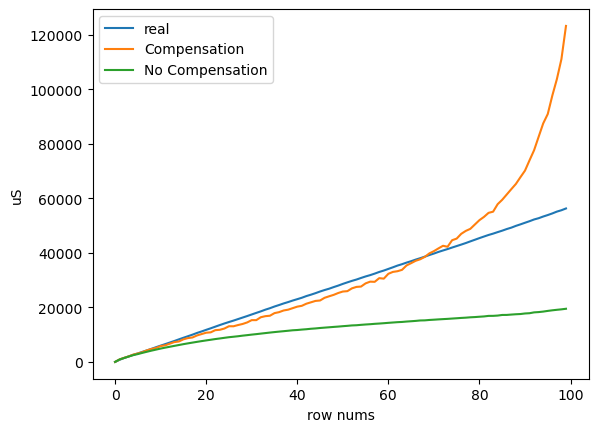

In [ ]:
plt.plot(change256[:,0],label = "real")
plt.plot(change256[:,1],label = "Compensation")
plt.plot(change256[:,2],label ="No Compensation")
ans = change256[:,0]-change256[:,1]
print(ans[:50])
# plt.title("")
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

In [ ]:
need_read = np.zeros((256,256),dtype=bool)
weight_pos = np.ix_([i for i in range(90,92)],[100])
need_read[weight_pos] = True

voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)[weight_pos]
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)[weight_pos]
print(np.max(voltage))
print(chip.voltage_to_cond(voltage=voltage-voltage_base))

voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=3,from_row=True,out_type=0)[weight_pos]
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=0)[weight_pos]
print(np.max(voltage))
print(chip.voltage_to_cond(voltage=voltage-voltage_base))
# print(voltage[weight_pos])
# real_r = chip.voltage_to_resistance(voltage = voltage)[weight_pos] - r_out[col]*1e-3
# real_cond = 1/real_r*1e3
# print(real_cond)